# Clase 7: Ejercicios — Solución
## AMLO vs Sheinbaum — Comentarios de YouTube

**Explicación del flujo:**

**Configuración**: Se preparan las herramientas necesarias y se conecta la clave de acceso de YouTube de forma segura para proteger las credenciales.

**Métricas**: Se extrae la información básica del video, como el número de visualizaciones, los likes y la cantidad total de comentarios.

**Descarga**: Se recopilan los comentarios en bloques de 50 en 50 hasta alcanzar un aproximado de 150.

**Limpieza**: Se elimina el código residual (como etiquetas HTML o caracteres especiales) y se descartan los textos excesivamente cortos.

**Análisis**: Se procesan y cruzan los datos finales para generar comparativas y responder a los objetivos del proyecto.

In [1]:
%%capture
pip install google-api-python-client transformers torch pandas matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import torch
from google.colab import userdata
from googleapiclient.discovery import build
from transformers import pipeline

YOUTUBE_API_KEY = userdata.get('YOUTUBE_API_KEY')
VIDEO_AMLO      = "ZTU-y38SBk8"
VIDEO_SHEINBAUM = "dVjnggFAmJc"

youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)
print("Cargando modelo...")
clasificador = pipeline("zero-shot-classification",
                        model="facebook/bart-large-mnli", device=0)
print("Listo ✓")

Cargando modelo...


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Listo ✓


## Parte 1 — Estadísticas (diccionarios)

 ¿Cuánto pesa cada video? Antes de meterse a leer comentarios, se quiere saber qué es lo que se está comparando

In [3]:
def obtener_stats(video_id):
    resp = youtube.videos().list(part='snippet,statistics', id=video_id).execute()
    v    = resp['items'][0]
    return {
        'titulo'     : v['snippet']['title'],
        'fecha'      : v['snippet']['publishedAt'][:10],
        'vistas'     : int(v['statistics'].get('viewCount', 0)),
        'likes'      : int(v['statistics'].get('likeCount', 0)),
        'comentarios': int(v['statistics'].get('commentCount', 0))
    }

stats_amlo      = obtener_stats(VIDEO_AMLO)
stats_sheinbaum = obtener_stats(VIDEO_SHEINBAUM)

**Ejercicio 1.**

**¿Qué se está midiendo?**
- `engagement = likes / vistas * 100` → Mide qué porcentaje de los que vieron dieron like. Es más comparable entre videos de distinto tamaño que el número absoluto de likes.
- `mas_vistas` usa un `if` en una línea para decidir qué string devolver.
- `diferencia_vistas` usa `abs()` para garantizar que sea positivo.

In [4]:
comparacion = {
    'engagement_amlo'      : stats_amlo['likes'] / stats_amlo['vistas'] * 100,
    'engagement_sheinbaum' : stats_sheinbaum['likes'] / stats_sheinbaum['vistas'] * 100,
    'mas_vistas'           : 'AMLO' if stats_amlo['vistas'] > stats_sheinbaum['vistas'] else 'Sheinbaum',
    'diferencia_vistas'    : abs(stats_amlo['vistas'] - stats_sheinbaum['vistas'])
}

for clave, valor in comparacion.items():
    print(f"{clave}: {valor}")

engagement_amlo: 8.248290405001034
engagement_sheinbaum: 8.562978207431076
mas_vistas: AMLO
diferencia_vistas: 1490


## Parte 2 — Descargar y clasificar



**limpieza:** Hay que quitar el texto que da YouTube: (`<br>` para saltos de línea, `&amp;` para el símbolo `&`).

**zero-shot classification:** *Zero-shot* significa que el modelo puede clasificar en categorías que nunca vio, basándose en qué tan probable es que el texto pertenezca a cada una según su entendimiento del lenguaje.

In [10]:
def descargar_y_limpiar(video_id, nombre, max_comentarios=150):
    comentarios = []
    page_token  = None
    while len(comentarios) < max_comentarios:
        resp = youtube.commentThreads().list(
            part='snippet', videoId=video_id,
            maxResults=min(100, max_comentarios - len(comentarios)),
            order='relevance', pageToken=page_token
        ).execute()
        for item in resp['items']:
            s = item['snippet']['topLevelComment']['snippet']
            comentarios.append({'texto': s['textDisplay'],
                                'likes': s['likeCount'],
                                'respuestas': item['snippet']['totalReplyCount']})
        page_token = resp.get('nextPageToken')
        if not page_token: break
    df = pd.DataFrame(comentarios)
    df['texto_limpio'] = (df['texto']
        .str.replace('<br>', ' ', regex=False)
        .str.replace('&amp;', '&', regex=False)
        .str.strip())
    df = df[df['texto_limpio'].str.len() >= 15].reset_index(drop=True)
    df['video'] = nombre
    print(f"{nombre}: {len(df)} comentarios ✓")
    return df

CATEGORIAS = [
    "En apoyo al gobierno",
    "Crítica u oposición al gobierno",
    "Humor o sarcasmo",
    "Spam o irrelevante"
]

def clasificar(df):
    cats, scores = [], []
    for i, texto in enumerate(df['texto_limpio']):
        r = clasificador(texto, CATEGORIAS)
        cats.append(r['labels'][0])
        scores.append(r['scores'][0])
        if (i+1) % 50 == 0: print(f"  {i+1}/{len(df)}...")
    df = df.copy()
    df['categoria'] = cats
    df['score']     = scores
    return df

df_amlo      = clasificar(descargar_y_limpiar(VIDEO_AMLO,      'AMLO'))
df_sheinbaum = clasificar(descargar_y_limpiar(VIDEO_SHEINBAUM, 'Sheinbaum'))
df_total     = pd.concat([df_amlo, df_sheinbaum], ignore_index=True)
print("Listo ✓")

AMLO: 148 comentarios ✓
  50/148...
  100/148...
Sheinbaum: 140 comentarios ✓
  50/140...
  100/140...
Listo ✓


## Parte 3 — Listas y tuplas

**Ejercicio 2.** Se construyen listas a partir de una columna del DataFrame, luego se emparejan con `zip`.

El top de likes es un proxy decente de "lo que más resonó".

In [11]:
amlo = df_total[df_total['video'] == 'AMLO']

textos_amlo = [texto for texto in amlo['texto_limpio']]
likes_amlo  = [likes for likes in amlo['likes']]

pares_amlo = sorted(
    [(texto, likes) for texto, likes in zip(textos_amlo, likes_amlo)],
    key=lambda par: par[1],
    reverse=True
)

print("Top 3 comentarios de AMLO por likes:")
for texto, likes in pares_amlo[:3]:
    print(f"  [{likes} likes] {texto[:80]}")

Top 3 comentarios de AMLO por likes:
  [255 likes] Reporteros de México.  Respeten al pueblo y  serán respetados.
  [222 likes] Dijeron que al año las “Mañaneras” ya iban a enfadar pero... !No , cada día está
  [195 likes] AYER EN EL ZÓCALO NUESTRO PRESIDENTE DEJÓ EN CLARO QUE ES EL NÚMERO UNO.


**Ejercicio 3.**

Para cada uno se quieren tres números... Si el video de Sheinbaum tiene muchos comentarios y la categoría dominante es "apoyo", eso ya comunica algo.

In [12]:
resumen = {}

for nombre in ['AMLO', 'Sheinbaum']:
    grupo = df_total[df_total['video'] == nombre]

    n_comentarios  = len(grupo)
    likes_promedio = round(grupo['likes'].mean(), 1)
    cat_frecuente  = grupo['categoria'].value_counts().index[0]

    resumen[nombre] = (n_comentarios, likes_promedio, cat_frecuente)

for video, (n, lk, cat) in resumen.items():
    print(f"{video}: {n} comentarios | {lk} likes promedio | categoría más frecuente: {cat}")

AMLO: 148 comentarios | 35.9 likes promedio | categoría más frecuente: Humor o sarcasmo
Sheinbaum: 140 comentarios | 7.2 likes promedio | categoría más frecuente: En apoyo al gobierno


## Parte 4 — Visualización

**Ejercicio 4.**

Los porcentajes se ven mejor en barras. Se ponen los videos lado a lado para que pueda apreciarse mejor la comparación.

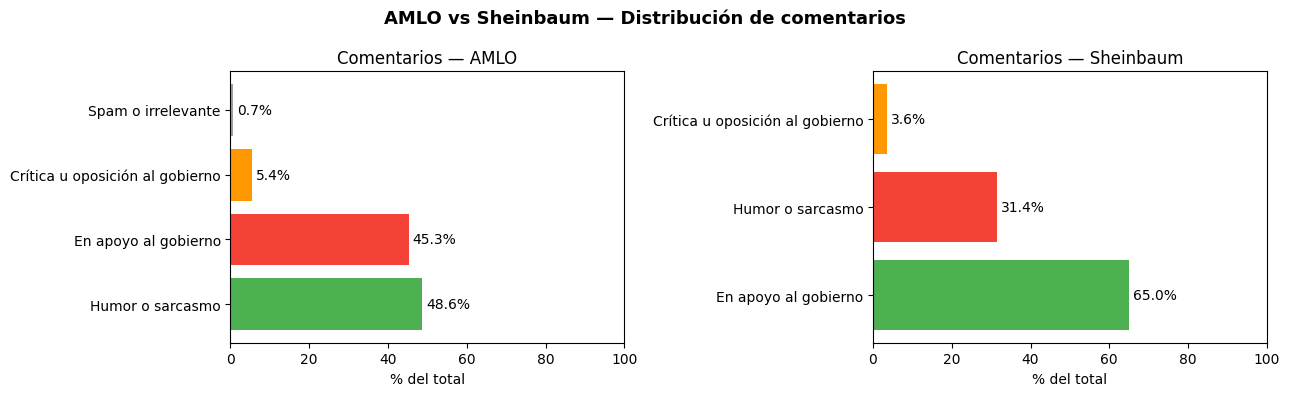

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colores = ['#4CAF50', '#F44336', '#FF9800', '#9E9E9E']

for ax, (nombre, grupo) in zip(axes, df_total.groupby('video')):
    pct = grupo['categoria'].value_counts() / len(grupo) * 100

    ax.barh(pct.index, pct.values, color=colores)

    ax.set_title(f'Comentarios — {nombre}', fontsize=12)
    ax.set_xlabel('% del total')
    ax.set_xlim(0, 100)
    for i, v in enumerate(pct.values):
        ax.text(v + 1, i, f'{v:.1f}%', va='center')

fig.suptitle('AMLO vs Sheinbaum — Distribución de comentarios',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Ejercicio 5** Aquí se ve si la gente está echando flores o tirando dardos.

In [14]:
for nombre in ['AMLO', 'Sheinbaum']:
    print(f"\nTop 3 — {nombre}")
    top3 = (df_total[df_total['video'] == nombre]
            .sort_values('likes', ascending=False)
            .head(3))
    for _, fila in top3.iterrows():
        print(f"  [{fila['likes']} likes | {fila['categoria']}] {fila['texto_limpio'][:80]}")


Top 3 — AMLO
  [255 likes | En apoyo al gobierno] Reporteros de México.  Respeten al pueblo y  serán respetados.
  [222 likes | Humor o sarcasmo] Dijeron que al año las “Mañaneras” ya iban a enfadar pero... !No , cada día está
  [195 likes | Humor o sarcasmo] AYER EN EL ZÓCALO NUESTRO PRESIDENTE DEJÓ EN CLARO QUE ES EL NÚMERO UNO.

Top 3 — Sheinbaum
  [49 likes | En apoyo al gobierno] Indiscutiblemen Nuestra Presidenta Siempre cerca de la gente Trabajando por su B
  [45 likes | En apoyo al gobierno] Buenos días a nuestra Presidenta Claudia Sheima y muchas bendiciones ❤️ 🙏
  [38 likes | Humor o sarcasmo] EXELENTE PRESIDENTA 👍🏾
